# 07 · When the Shared Knowledge Does Not Apply

Every chapter so far drew new systems from the same family the pretrained model was built on. Real
deployments are not always this polite: a worn bearing, a manufacturing defect, or simply a
different product line can push a new system outside what pretraining ever saw. This chapter asks
what happens then, and whether we can notice it.

---
## 1. Moving outside the learned family

The pretrained model is only as good as the family it has seen. What happens when a new system
varies in a way **never seen during pretraining**, e.g. a worn bearing changing damping and gain in
an unusual combination? We move the true coefficients a distance $\delta$ away from the learned
family, along a direction orthogonal to $U$, and adapt with 12 s of data. A two-number context
cannot represent the change.

The adaptation itself offers a warning signal: the **output misfit**, already returned by `adapt` in
chapter 04. If the best context still cannot explain the data, the residual is larger than it is for
normal members of the family. We calibrate a threshold as the 95th percentile of the misfit on
in-family systems.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import dynutils
from dynutils import sample_system, simulate, multisine, predict, fit_from_scratch, adapt, rmse

dynutils.set_style()
rng = np.random.default_rng(dynutils.SEED)
COLOR = dynutils.COLOR
family, train_systems, train_data, train_fits = dynutils.build_family(rng)

---
## 2. Does the pretrained model degrade, and can we detect it?

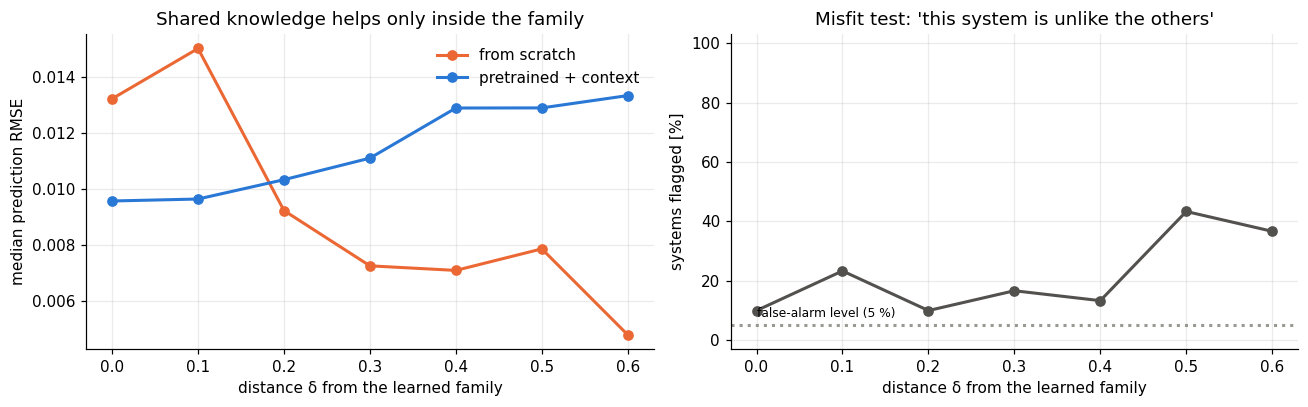

direction of change in [k, d, b, α]: [ 0.33  0.88 -0.24 -0.24]
delta=0.0: scratch median RMSE=0.0132  context median RMSE=0.0096  flagged=10%
delta=0.1: scratch median RMSE=0.0150  context median RMSE=0.0096  flagged=23%
delta=0.2: scratch median RMSE=0.0092  context median RMSE=0.0103  flagged=10%
delta=0.3: scratch median RMSE=0.0072  context median RMSE=0.0111  flagged=17%
delta=0.4: scratch median RMSE=0.0071  context median RMSE=0.0129  flagged=13%
delta=0.5: scratch median RMSE=0.0079  context median RMSE=0.0129  flagged=43%
delta=0.6: scratch median RMSE=0.0048  context median RMSE=0.0133  flagged=37%


In [2]:
T = 120
basis_out = np.linalg.svd(family.U, full_matrices=True)[0][:, 2:]   # directions the context cannot express
direction = basis_out[:, np.argmax(np.abs(basis_out[1]))]          # the one that moves damping most
direction *= np.sign(direction[1]) / np.linalg.norm(direction)

in_family = []
for _ in range(60):
    s = sample_system(rng); u = multisine(T, rng)
    in_family.append(adapt(family, simulate(s, u, rng)[1], u)[2])
threshold = np.quantile(in_family, 0.95)

shifts = np.linspace(0, 0.6, 7)
shift_err = {m: np.zeros((len(shifts), 30)) for m in ("scratch", "context")}
flagged = np.zeros((len(shifts), 30), bool)
for i, delta in enumerate(shifts):
    for n in range(30):
        s = sample_system(rng)
        s["eta"] = np.clip(s["eta"] + delta * direction, dynutils.LOW + 0.02, dynutils.HIGH)
        u = multisine(T, rng); _, y = simulate(s, u, rng)
        u_val = multisine(300, rng, n=6); q_val, _ = simulate(s, u_val, rng, noise=False)
        z_, _, misfit = adapt(family, y, u)
        shift_err["context"][i, n] = rmse(predict(family.decode(z_), u_val), q_val)
        shift_err["scratch"][i, n] = rmse(predict(fit_from_scratch(y, u), u_val), q_val)
        flagged[i, n] = misfit > threshold

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
for m, lab in (("scratch", "from scratch"), ("context", "pretrained + context")):
    ax1.plot(shifts, np.median(shift_err[m], axis=1), marker="o", color=COLOR[m], label=lab)
ax1.set(xlabel="distance δ from the learned family", ylabel="median prediction RMSE",
        title="Shared knowledge helps only inside the family"); ax1.legend()
ax2.plot(shifts, 100 * flagged.mean(axis=1), marker="o", color=COLOR["reference"])
ax2.axhline(5, ls=":", color=COLOR["none"]); ax2.text(0.0, 8, "false-alarm level (5 %)", fontsize=8)
ax2.set(xlabel="distance δ from the learned family", ylabel="systems flagged [%]", ylim=(-3, 103),
        title="Misfit test: 'this system is unlike the others'")
plt.tight_layout(); plt.show()
print("direction of change in [k, d, b, α]:", np.round(direction, 2))
for i, delta in enumerate(shifts):
    print(f"delta={delta:.1f}: scratch median RMSE={np.median(shift_err['scratch'][i]):.4f}  "
          f"context median RMSE={np.median(shift_err['context'][i]):.4f}  flagged={100*flagged[i].mean():.0f}%")


As the new system leaves the family, the pretrained model gets steadily worse, while the
from-scratch estimate is unaffected: it assumes nothing about the family. (Its error even
decreases, since more strongly damped systems move less and are easier to predict.) With 12 s of
data, from scratch is already competitive inside the family, so the pretrained model loses its
advantage after a small shift.

The misfit test responds as it should. It flags about 5% of normal systems, as designed, and its
detection rate rises with the shift to roughly three quarters of the systems. But **detection
lags degradation**: at moderate shifts the adapter is already worse than from scratch, while most
systems still pass the test, because the misfit is dominated by the disturbance.

This yields a simple decision rule: *use the small adapter while it explains the data, and fall back
to (or enlarge towards) full identification when it does not.* Making such a rule both sensitive
and trustworthy, with guarantees, is an open question for learned models.

---
## Exercises

### Exercise 1: A direction that stays inside the family
Repeat the shift study, but move along a direction *inside* `family.U` (e.g. `family.U[:, 0] /
np.linalg.norm(family.U[:, 0])`) instead of `direction`. Does the pretrained model degrade, and does
the misfit test flag anything?

<details><summary>Solution</summary>

```python
inside = family.U[:, 0] / np.linalg.norm(family.U[:, 0])
errs_inside, flags_inside = [], []
for n in range(30):
    s = sample_system(rng)
    s["eta"] = np.clip(s["eta"] + 0.4 * inside, dynutils.LOW + 0.02, dynutils.HIGH)
    u = multisine(T, rng); _, y = simulate(s, u, rng)
    u_val = multisine(300, rng, n=6); q_val, _ = simulate(s, u_val, rng, noise=False)
    z_, _, misfit = adapt(family, y, u)
    errs_inside.append(rmse(predict(family.decode(z_), u_val), q_val)); flags_inside.append(misfit > threshold)
np.median(errs_inside), np.mean(flags_inside)
```
Moving along a direction the context *can* represent leaves both the error and the flag rate close
to the in-family baseline, since `adapt` can simply find a `z` that reaches that part of coefficient
space — confirming that it is specifically the *unrepresentable* component of a shift that hurts.
</details>

### Exercise 2: A stricter threshold
Recompute `threshold` at the 99th percentile instead of the 95th. How does the false-alarm rate on
in-family systems and the detection rate at $\delta=0.3$ change?

<details><summary>Solution</summary>

```python
threshold_99 = np.quantile(in_family, 0.99)
delta = 0.3
misfits = []
for n in range(30):
    s = sample_system(rng)
    s["eta"] = np.clip(s["eta"] + delta * direction, dynutils.LOW + 0.02, dynutils.HIGH)
    u = multisine(T, rng); _, y = simulate(s, u, rng)
    misfits.append(adapt(family, y, u)[2])
np.mean(in_family > threshold_99), np.mean(np.array(misfits) > threshold_99)
```
Raising the threshold from the 95th to the 99th percentile roughly quarters the expected false-alarm
rate on in-family systems (5% to about 1% by construction) but also detects fewer of the shifted
systems at any given δ, since the same trade-off between false alarms and detection lag applies here
as to any anomaly threshold.
</details>